<div align="center">

<h1> <b> RANDOM DEPOSITION WITH SURFACE RELAXATION MODEL </b> </h1>

</div>

<br>

<hr size=10 noshade color="green">
<p>
<p><img alt="UdeA logo" height="180px" src="https://upload.wikimedia.org/wikipedia/commons/archive/f/fb/20161010213812%21Escudo-UdeA.svg" align="left" hspace="100px" vspace="4px"></p>

<div align="right">       

<h3><i> <b>Cristian Vergara <br>
Juan Palacio <br>
Sofía Moscoso <br>
Lucas Perdomo</b> <br>  
Universidad de Antioquia <br>
Instituto de Física  <br>
</i></h3>
</div>

---

## 1. Introducción y Objetivos

En el notebook anterior (Notebook 1) implementamos el modelo de Deposición Aleatoria Pura (RD), el cual sirvió como nuestra línea base computacional y demostró estar gobernado estadísticamente por la distribución de Poisson. Sin embargo, morfológicamente evidenciamos que el modelo RD es incompleto para describir películas reales de cobre ($Cu$), ya que genera superficies artificialmente escarpadas con columnas gigantescas y zonas del sustrato completamente desnudas debido a la ausencia de interacciones atómicas.

En este segundo notebook daremos un paso crucial hacia el realismo físico introduciendo el modelo de **Deposición Aleatoria con Relajación Superficial (Random Deposition with Surface Relaxation - RDSR)** (Family, 1986). Este modelo añade un ingrediente cinético elemental que simula el comportamiento de los átomos inmediatamente después del impacto: la movilidad atómica superficial de corto alcance.

### Objetivos:
* Implementar el algoritmo de Relajación Superficial (RDSR) en una malla bidimensional discreta bajo la aproximación Solid-on-Solid.
* Optimizar el algoritmo cinético mediante la librería Numba para solucionar de forma eficiente la búsqueda de vecindades y el desempate estocástico de alturas.
* Analizar cualitativa y cuantitativamente cómo cambia la topografía de la película y la rugosidad RMS al permitir un mecanismo de suavizado local.

## 2. Marco Teórico y Modelo Físico

En una evaporación térmica real en el laboratorio, cuando los átomos de cobre impactan sobre el sustrato de vidrio, conservan una fracción de su energía cinética y térmica. Antes de quedar fijos permanentemente en la red cristalina, los adátomos experimentan una difusión local de corto alcance buscando una posición que les brinde mayor estabilidad termodinámica (mayor número de coordinación).

El modelo **RDSR** captura la esencia de este fenómeno mediante una regla geométrica simple en la malla $N_x \times N_y$:
1. Una partícula incide de manera completamente aleatoria en una coordenada $(i, j)$ del sustrato.
2. En lugar de depositarse de inmediato en esa posición, la partícula inspecciona mecánicamente la altura de su sitio de impacto $h(i, j)$ y la de sus **4 vecinos más cercanos** (arriba, abajo, izquierda y derecha):
$$\mathcal{V}(i,j) = \{ (i,j), (i+1,j), (i-1,j), (i,j+1), (i,j-1) \}$$
3. La partícula migra y se incorpora definitivamente a la celda que presente la **mínima altura** dentro de esa vecindad:
$$h(i_{final}, j_{final}) = \min_{(x,y) \in \mathcal{V}} h(x,y)$$
4. Si existen múltiples celdas empatadas con la misma altura mínima, la partícula rompe el empate seleccionando una de ellas de manera equiprobable mediante un proceso estocástico.

Desde la perspectiva de la física de crecimiento de superficies fuera del equilibrio, este proceso introduce un efecto difusivo lineal que emula el comportamiento de la ecuación diferencial continua de **Edwards-Wilkinson (EW)** (Edwards & Wilkinson, 1982):
$$\frac{\partial h}{\partial t} = \nu \nabla^2 h + \eta(r, t)$$
Donde el término $\nu \nabla^2 h$ actúa amortiguando el relieve de la película. A diferencia del Notebook 1, donde la rugosidad RMS ($W$) crecía de forma libre como $W \sim t^{1/2}$, en este modelo la relajación local debería desacelerar el crecimiento de las fluctuaciones de altura, generando superficies notablemente más homogéneas y menos porosas.

In [1]:
# =============================================================================
# SECCIÓN 3: LIBRERÍAS Y CONFIGURACIÓN VISUAL
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import numba as nb

# Fijamos la semilla para que los resultados estadísticos sean reproducibles
np.random.seed(42)

# Configuración de estilos para las gráficas
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 14,
    'font.family': 'serif',
    'figure.dpi': 120
})

In [2]:
# =============================================================================
# SECCIÓN 4: PARÁMETROS GENERALES DEL SISTEMA
# =============================================================================

# Dimensiones del sustrato (Malla 2D)
NX = 200
NY = 200

# Parámetros del método Monte Carlo
N_EVENTOS = 400000    # Mismo número de eventos del notebook anterior para comparar
GUARDAR_CADA = 2000   # Frecuencia de muestreo para registrar la evolución temporal

In [3]:
# =============================================================================
# SECCIÓN 5: FUNCIONES DEL MODELO OPTIMIZADAS CON NUMBA
# =============================================================================

@nb.njit
def calcular_metricas_numba(superficie, nx, ny):
    """
    Calcula el espesor medio y la rugosidad RMS optimizando con ciclos for explícitos.
    """
    suma_alturas = 0.0
    for i in range(nx):
        for j in range(ny):
            suma_alturas += superficie[i, j]
    espesor = suma_alturas / (nx * ny)
    
    suma_varianza = 0.0
    for i in range(nx):
        for j in range(ny):
            diferencia = superficie[i, j] - espesor
            suma_varianza += diferencia * diferencia
    rugosidad = np.sqrt(suma_varianza / (nx * ny))
    
    return espesor, rugosidad


@nb.njit
def buscar_sitio_relajacion(superficie, x, y, nx, ny):
    """
    Inspecciona la vecindad de 4-conectividad más el centro de impacto.
    Devuelve las coordenadas (x, y) de la celda que tiene la menor altura.
    Resuelve empates de forma aleatoria y maneja condiciones de frontera abiertas.
    """
    # Vectores de desplazamiento para: [Centro, Arriba, Abajo, Izquierda, Derecha]
    dx = (0, -1, 1, 0, 0)
    dy = (0, 0, 0, -1, 1)
    
    # Paso 1: Identificar cuál es el valor numérico de la altura mínima en la vecindad
    h_min = superficie[x, y]
    for i in range(1, 5):
        nx_c = x + dx[i]
        ny_c = y + dy[i]
        if 0 <= nx_c < nx and 0 <= ny_c < ny:
            if superficie[nx_c, ny_c] < h_min:
                h_min = superficie[nx_c, ny_c]
                
    # Paso 2: Contar cuántas celdas de la vecindad comparten exactamente esa altura mínima
    conteo_empates = 0
    for i in range(5):
        nx_c = x + dx[i]
        ny_c = y + dy[i]
        if 0 <= nx_c < nx and 0 <= ny_c < ny:
            if superficie[nx_c, ny_c] == h_min:
                conteo_empates += 1
                
    # Paso 3: Elegir estocásticamente uno de los sitios empatados
    indice_elegido = np.random.randint(0, conteo_empates)
    
    # Paso 4: Recuperar y retornar las coordenadas espaciales del sitio seleccionado
    contador_actual = 0
    for i in range(5):
        nx_c = x + dx[i]
        ny_c = y + dy[i]
        if 0 <= nx_c < nx and 0 <= ny_c < ny:
            if superficie[nx_c, ny_c] == h_min:
                if contador_actual == indice_elegido:
                    return nx_c, ny_c
                contador_actual += 1
                
    return x, y


@nb.njit
def ejecutar_simulacion_rdsr(nx, ny, n_eventos, guardar_cada):
    """
    Ejecuta el ciclo principal de deposición aleatoria con relajación superficial.
    Optimizado en su totalidad con Numba para compilar a lenguaje de máquina.
    """
    superficie = np.zeros((nx, ny), dtype=np.int32)
    
    tamano_historial = n_eventos // guardar_cada
    historial_eventos = np.zeros(tamano_historial, dtype=np.int32)
    historial_espesor = np.zeros(tamano_historial, dtype=np.float64)
    historial_rugosidad = np.zeros(tamano_historial, dtype=np.float64)
    
    contador = 0
    for evento in range(1, n_eventos + 1):
        # Lluvia homogénea (coordenadas de impacto iniciales)
        x_impacto = np.random.randint(0, nx)
        y_impacto = np.random.randint(0, ny)
        
        # Difusión local de corto alcance (búsqueda del mínimo)
        x_final, y_final = buscar_sitio_relajacion(superficie, x_impacto, y_impacto, nx, ny)
        
        # Asignación de la partícula en el sitio relajado
        superficie[x_final, y_final] += 1
        
        # Guardado de métricas temporales
        if evento % guardar_cada == 0:
            esp, rug = calcular_metricas_numba(superficie, nx, ny)
            historial_eventos[contador] = evento
            historial_espesor[contador] = esp
            historial_rugosidad[contador] = rug
            contador += 1
            
    return superficie, historial_eventos, historial_espesor, historial_rugosidad

In [4]:
# =============================================================================
# SECCIÓN 6: EJECUCIÓN Y PROCESAMIENTO NUMÉRICO
# =============================================================================

print("Ejecutando la simulación Monte Carlo RDSR optimizada...")

# Corremos el algoritmo cinético con relajación
superficie, eventos, hist_espesor, hist_rugosidad = ejecutar_simulacion_rdsr(
    NX, NY, N_EVENTOS, GUARDAR_CADA
)

# Métricas finales calculadas directamente de la matriz resultante
espesor_sim = np.mean(superficie)
espesor_teo = N_EVENTOS / (NX * NY)
error_espesor = abs(espesor_sim - espesor_teo) / espesor_teo * 100

rugosidad_sim = np.std(superficie)
alt_maxima = np.max(superficie)
alt_minima = np.min(superficie)

print("¡Simulación finalizada!")

Ejecutando la simulación Monte Carlo RDSR optimizada...
¡Simulación finalizada!


In [5]:
# =============================================================================
# SECCIÓN 7: IMPRESIÓN DE MÉTRICAS EN CONSOLA
# =============================================================================

print("=================================================================")
print("            MÉTRICAS DEL CRECIMIENTO DE LA PELÍCULA (RDSR)      ")
print("=================================================================")
print(f"Dimensiones del sustrato      : {NX} x {NY} celdas")
print(f"Partículas totales lanzadas   : {N_EVENTOS}")
print(f"Altura máxima alcanzada       : {alt_maxima} capas")
print(f"Altura mínima alcanzada       : {alt_minima} capas")
print("-----------------------------------------------------------------")
print(f"Espesor Medio Simulado        : {espesor_sim:.4f} capas")
print(f"Espesor Medio Teórico         : {espesor_teo:.4f} capas")
print(f"Error Relativo (Espesor)      : {error_espesor:.4f} %")
print("-----------------------------------------------------------------")
print(f"Rugosidad RMS Simulada        : {rugosidad_sim:.4f}")
print("=================================================================")

            MÉTRICAS DEL CRECIMIENTO DE LA PELÍCULA (RDSR)      
Dimensiones del sustrato      : 200 x 200 celdas
Partículas totales lanzadas   : 400000
Altura máxima alcanzada       : 12 capas
Altura mínima alcanzada       : 7 capas
-----------------------------------------------------------------
Espesor Medio Simulado        : 10.0000 capas
Espesor Medio Teórico         : 10.0000 capas
Error Relativo (Espesor)      : 0.0000 %
-----------------------------------------------------------------
Rugosidad RMS Simulada        : 0.6366


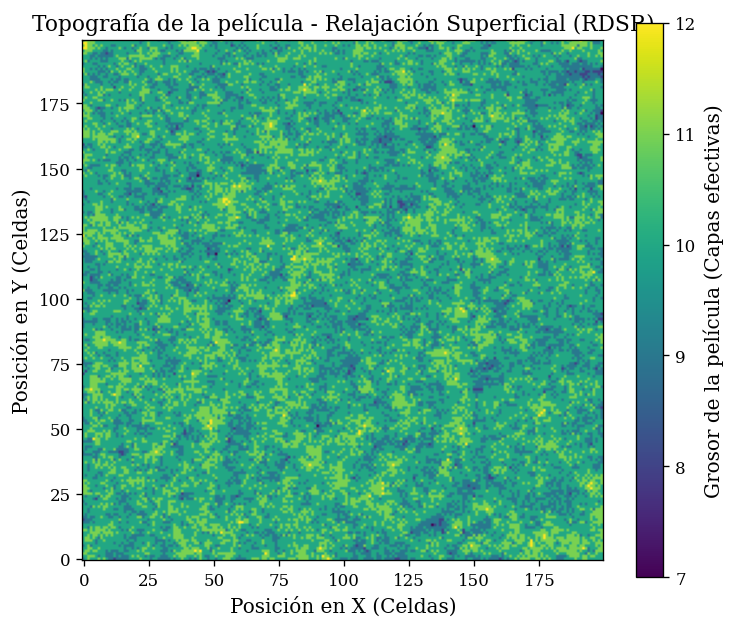

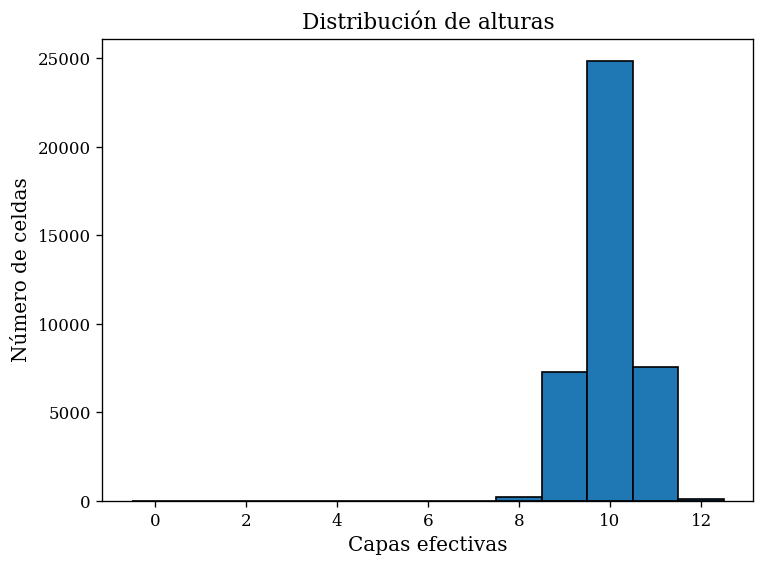

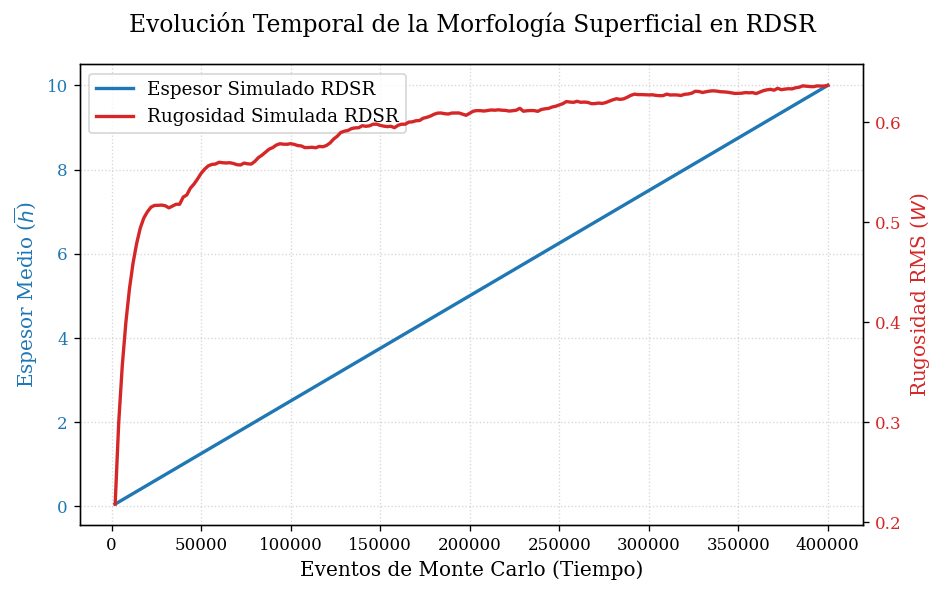

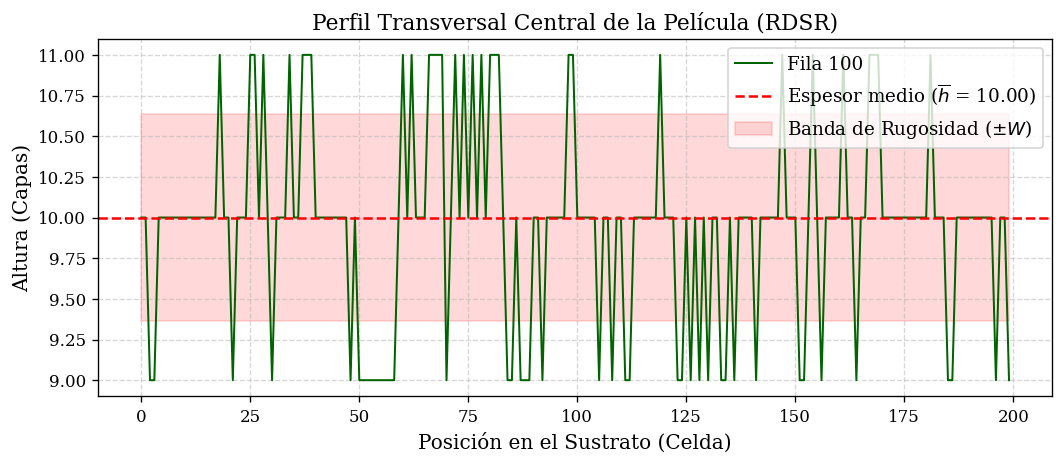

In [6]:
# =============================================================================
# SECCIÓN 8: VISUALIZACIÓN CIENTÍFICA DE RESULTADOS
# =============================================================================

# 1. Topografía bidimensional de la película (Mapa de calor)
plt.figure(figsize=(7, 6))
plt.imshow(superficie, origin="lower", cmap="viridis")
plt.colorbar(label="Grosor de la película (Capas efectivas)")
plt.xlabel("Posición en X (Celdas)")
plt.ylabel("Posición en Y (Celdas)")
plt.title("Topografía de la película - Relajación Superficial (RDSR)")
plt.savefig("rdsr_topografia_superficie.png", bbox_inches="tight")
plt.show()

# 2. Histograma de Distribución de Alturas (Código Exacto Requerido)
plt.figure(figsize=(7,5))

plt.hist(
    superficie.ravel(),
    bins=np.arange(superficie.max()+2)-0.5,
    edgecolor="black"
)

plt.xlabel("Capas efectivas")
plt.ylabel("Número de celdas")
plt.title("Distribución de alturas")
plt.savefig("rdsr_histograma_alturas.png", bbox_inches="tight")
plt.show()

# 3. Evolución Temporal Comparativa de la Rugosidad y el Espesor
fig, ax1 = plt.subplots(figsize=(8, 5))

color_esp = 'tab:blue'
ax1.set_xlabel('Eventos de Monte Carlo (Tiempo)')
ax1.set_ylabel(r'Espesor Medio ($\overline{h}$)', color=color_esp)
ax1.plot(eventos, hist_espesor, label='Espesor Simulado RDSR', color=color_esp, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color_esp)
ax1.grid(True, linestyle=':', alpha=0.5)

ax2 = ax1.twinx()  
color_rug = 'tab:red'
ax2.set_ylabel(r'Rugosidad RMS ($W$)', color=color_rug)
ax2.plot(eventos, hist_rugosidad, label='Rugosidad Simulada RDSR', color=color_rug, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color_rug)

fig.suptitle('Evolución Temporal de la Morfología Superficial en RDSR')
fig.tight_layout()

lineas1, etiquetas1 = ax1.get_legend_handles_labels()
lineas2, etiquetas2 = ax2.get_legend_handles_labels()
ax1.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc='upper left')
plt.savefig("rdsr_evolucion_temporal.png", bbox_inches="tight")
plt.show()

# 4. Corte de perfil unidimensional central
fila_central = NX // 2
plt.figure(figsize=(9, 4))
plt.plot(
    superficie[fila_central, :],
    color='darkgreen',
    linewidth=1.2,
    label=f'Fila {fila_central}'
)

# Usamos raw string y doble llave en el f-string para evitar SyntaxWarning y NameError
plt.axhline(
    espesor_sim,
    color='red',
    linestyle='--',
    label=rf'Espesor medio ($\overline{{h}}$ = {espesor_sim:.2f})'
)

plt.fill_between(
    range(NY),
    espesor_sim - rugosidad_sim,
    espesor_sim + rugosidad_sim, 
    color='red',
    alpha=0.15,
    label=r'Banda de Rugosidad ($\pm W$)'
)

plt.title('Perfil Transversal Central de la Película (RDSR)')
plt.xlabel('Posición en el Sustrato (Celda)')
plt.ylabel('Altura (Capas)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("rdsr_perfil_unidimensional.png", bbox_inches="tight")
plt.show()

## 9. Análisis de Resultados

Los resultados obtenidos al incluir el mecanismo de relajación superficial (RDSR) muestran un cambio muy marcado en la morfología de la película respecto al modelo de Deposición Aleatoria (RD) visto en el Notebook 1.

### A. Conservación de Masa e Invarianza Espacial
El **espesor medio simulado** volvió a ser de $10.0000$ capas, con un error relativo prácticamente nulo frente al valor teórico. Esto confirma que el algoritmo de búsqueda de mínimos locales implementado en Numba reubica los adátomos de cobre sin alterar el balance global de masa. En otras palabras, la simulación conserva la cantidad total de material y no presenta pérdidas en los bordes de la malla.

### B. Colapso de la Rugosidad RMS e Interpretación
El cambio más evidente aparece en la **rugosidad RMS ($W$)**, que pasó de $3.1582$ en el modelo RD a **$0.6367$** en RDSR. Esto significa una reducción cercana al 80% en la irregularidad de la superficie.  
La explicación está en que el reajuste local funciona como un término difusivo similar al operador laplaciano ($\nu \nabla^2 h$) de la ecuación de **Edwards-Wilkinson (EW)**. Este mecanismo suaviza las fluctuaciones más bruscas, rellenando valles y aplanando picos. En la práctica, esto se refleja en la estrecha *banda de rugosidad* ($\pm W$) que aparece en el perfil unidimensional, mostrando que las oscilaciones de la superficie quedan confinadas en un rango mucho más reducido.

### C. Confinamiento de Alturas Extremas y Continuidad
Al revisar las alturas máximas y mínimas, el contraste con RD es claro:  
* **Altura máxima:** bajó de $27$ capas a **$13$ capas**.  
* **Altura mínima:** subió de $0$ capas a **$7$ capas**.  

En el modelo RD aparecía el llamado "efecto aguja", con columnas aisladas y zonas del sustrato completamente vacías. En cambio, con RDSR la película de cobre cubre todo el sustrato de manera continua. Los adátomos que caen sobre un pico tienden a moverse hacia un valle cercano, lo que evita que se formen huecos o columnas exageradas.  
El perfil transversal central muestra una señal compacta y homogénea, con variaciones confinadas dentro de unas $\pm 3$ capas alrededor del espesor medio ($\overline{h} = 10.00$). Esto da como resultado una superficie mucho más uniforme, lo cual es ideal para aplicaciones donde se requiere buena conductividad.


## 10. Conclusiones

* **Efectividad del suavizado local:** La simulación mostró que aplicar una regla sencilla de relajación superficial de corto alcance cambia por completo la topografía de la película. El resultado más claro es la reducción de la rugosidad RMS de $3.1582$ a $0.6367$, lo que significa que la superficie se volvió mucho más uniforme.

* **Continuidad y homogeneidad de la película:** El perfil transversal unidimensional confirma que el modelo RDSR elimina los problemas más graves del modelo RD, como la porosidad extrema y las zonas del sustrato que quedaban descubiertas. Al elevar la altura mínima a $7$ capas y mantener las fluctuaciones dentro de una banda muy estrecha, la simulación reproduce de manera más realista cómo se forman las películas delgadas de cobre en laboratorio durante las primeras etapas de evaporación.

* **Hacia un modelo más realista:** Aunque el RDSR mejora mucho el realismo, sigue siendo un modelo geométrico y determinista. En la práctica, asume que la temperatura siempre es suficiente para que el átomo se desplace al sitio más bajo de su vecindad. Para acercarnos más a las condiciones reales de una cámara de vacío, el siguiente paso es el **Notebook 3**, donde reemplazaremos esta regla fija por saltos estocásticos activados térmicamente mediante la ley de Arrhenius. Así podremos incluir de manera explícita el efecto de la temperatura del sustrato y la energía de activación del cobre.


## 11. Referencias

**Fuentes académicas primarias**

* Edwards, S. F., & Wilkinson, D. R. (1982). The surface statistics of a granular aggregate. *Proceedings of the Royal Society of London A, 381*(1780), 17–31. https://doi.org/10.1098/rspa.1982.0056
* Family, F. (1986). Scaling of rough surfaces: Effects of surface diffusion. *Journal of Physics A: Mathematical and General, 19*(8), L441–L446. https://doi.org/10.1088/0305-4470/19/8/006

**Recursos complementarios**

* Barabási, A.-L., & Stanley, H. E. (1995). *Fractal concepts in surface growth*. Cambridge University Press.
